In [1]:
import pandas as pd
import json
from pathlib import Path
import requests
import os
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


N_CLUSTER = 8

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [2]:
FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

In [3]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [4]:
def advanced_clean_text(text):
    # Define domain-specific stopwords
    custom_stopwords = {'points', 'interest', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)

In [5]:
combined_details_df = pd.read_csv("../data/combined_details.csv")
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_28481/2128574053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [6]:
filtered_df = combined_details_df[(combined_details_df['tags']).str.lower().str.contains('landmark', na=False)]

In [7]:
filtered_df[['name', 'tags']]

,name,tags
5,Doi Chang Mub Arboretum,"Points of Interest & Landmarks, Lookouts"
7,Golden Triangle,Points of Interest & Landmarks
17,Wat Lai,Points of Interest & Landmarks
26,Wat Sao Thong Thong,"Points of Interest & Landmarks, Sacred & Relig..."
28,Kraison Siharat Hall,Points of Interest & Landmarks
...,...,...
1734,Wat Traphang Thong,"Points of Interest & Landmarks, Sacred & Relig..."
1736,Chiang Chom Temple (Wat Chedi Plong Pagoda),Points of Interest & Landmarks
1742,Ayutthaya Historical Park,"Historic Sites, Ancient Ruins, Architectural B..."
1745,Wat Wichian Bamrung,"Sacred & Religious Sites, Points of Interest &..."


In [8]:
combined_details_df['cleaned_tags'] = combined_details_df['tags'].apply(advanced_clean_text)

In [9]:
CONST_VECTOR_SIZE = 100
CONST_DIM_WINDOWS = 5

In [10]:
sentences = combined_details_df['cleaned_tags'].str.split()  # Tokenized tags
word2vec_model = Word2Vec(sentences, vector_size=CONST_VECTOR_SIZE, window=CONST_DIM_WINDOWS, min_count=1, workers=4)
# Compute TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(combined_details_df['cleaned_tags'])

In [11]:
def get_weighted_embedding(text):
    words = text.split()
    word_vecs = [word2vec_model.wv[word] * tfidf.idf_[tfidf.vocabulary_[word]] 
                 for word in words if word in word2vec_model.wv and word in tfidf.vocabulary_]
    return np.mean(word_vecs, axis=0) if word_vecs else np.zeros(word2vec_model.vector_size)

# Apply to dataset
combined_details_df['vectorized_tags'] = combined_details_df['cleaned_tags'].apply(get_weighted_embedding)

In [12]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# แปลงทุกประโยคเป็นเวกเตอร์
sentence_vectors = np.array([sentence_vector(sentence, word2vec_model) for sentence in sentences])


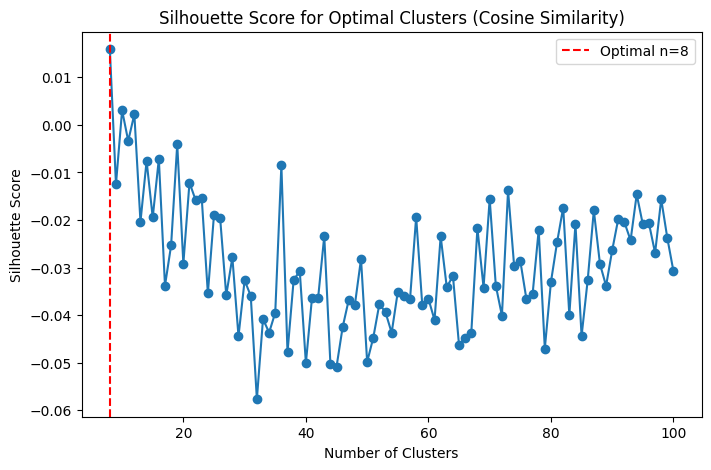

In [13]:
def find_optimal_clusters_cosine(data, min_clusters=2, max_clusters=10):
    best_n = min_clusters
    best_silhouette = -1
    silhouette_scores = []
    inertias = []
    
    for n in range(min_clusters, max_clusters + 1):
        kmeans = MiniBatchKMeans(n_clusters=n, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, labels)
        silhouette_scores.append(silhouette_avg)
        inertias.append(kmeans.inertia_)

        if silhouette_avg > best_silhouette:
            best_silhouette = silhouette_avg
            best_n = n

    # วาดกราฟ Elbow Method
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_clusters, max_clusters + 1), silhouette_scores, marker='o')
    plt.axvline(x=best_n, color='r', linestyle='--', label=f'Optimal n={best_n}')
    plt.title('Silhouette Score for Optimal Clusters (Cosine Similarity)')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.show()
    
    return best_n

# Example sentence_vectors
sentence_vectors = np.random.rand(100, 50)  # Replace this with actual Word2Vec or embedding data
BEST_OPTIMIZE_N_CLUSTER = find_optimal_clusters_cosine(sentence_vectors, min_clusters = 8, max_clusters=100)

In [14]:
def apply_kmeans(data, num_clusters=15):
    kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    
    # Compute Evaluation Metrics
    silhouette_avg = silhouette_score(data, labels)
    dbi_score = davies_bouldin_score(data, labels)

    print(f"Silhouette Score: {silhouette_avg}")
    print(f"Davies-Bouldin Index: {dbi_score}")

    return labels

In [15]:
print(f"best_n = {BEST_OPTIMIZE_N_CLUSTER}")

best_n = 8


In [16]:
labels = apply_kmeans(sentence_vectors, BEST_OPTIMIZE_N_CLUSTER)

Silhouette Score: 0.015883516187290087
Davies-Bouldin Index: 3.2613776215528


In [17]:
labels

array([0, 2, 0, 2, 5, 6, 7, 4, 5, 6, 7, 2, 2, 6, 5, 4, 6, 1, 2, 5, 2, 2,
       7, 2, 7, 7, 7, 7, 7, 5, 7, 2, 2, 7, 1, 5, 2, 7, 7, 5, 5, 5, 5, 4,
       7, 2, 2, 4, 1, 0, 1, 2, 1, 2, 0, 4, 2, 7, 3, 7, 3, 6, 7, 6, 7, 7,
       4, 5, 2, 6, 1, 4, 6, 7, 5, 2, 2, 7, 1, 0, 6, 7, 4, 1, 4, 3, 7, 2,
       2, 7, 2, 5, 4, 4, 0, 3, 7, 5, 6, 2], dtype=int32)

In [18]:
clusters = {i: [] for i in range(BEST_OPTIMIZE_N_CLUSTER)}
for i, label in enumerate(labels):
    clusters[label].append(sentences[i])

In [19]:
for cluster_id, items in clusters.items():
    print(f"\nCluster {cluster_id}:")
    print(items)


Cluster 0:
[['history', 'museum', 'specialty', 'museum'], ['sacred', 'religious'], ['waterfall'], ['point', 'landmark'], ['point', 'landmark'], ['point', 'landmark']]

Cluster 1:
[['point', 'landmark'], ['zoo'], ['flea', 'street', 'market'], ['scuba', 'snorkeling', 'adrenaline', 'extreme', 'tour'], ['point', 'landmark'], ['flea', 'street', 'market'], ['park'], ['beach']]

Cluster 2:
[['bar', 'club'], ['boat', 'tour'], ['flea', 'street', 'market'], ['shopping', 'mall'], ['performance'], ['sacred', 'religious'], ['sacred', 'religious'], ['geologic', 'formation'], ['sacred', 'religious'], ['nature', 'wildlife', 'area'], ['waterfall'], ['historic', 'point', 'landmark'], ['point', 'landmark'], ['point', 'landmark'], ['point', 'landmark', 'sacred', 'religious'], ['national', 'park'], ['railway'], ['shark', 'diving', 'scuba', 'snorkeling', 'boat', 'tour', 'water', 'sport'], ['history', 'museum', 'specialty', 'museum'], ['boat', 'tour', 'scuba', 'snorkeling', 'kayaking', 'canoeing', 'standup'

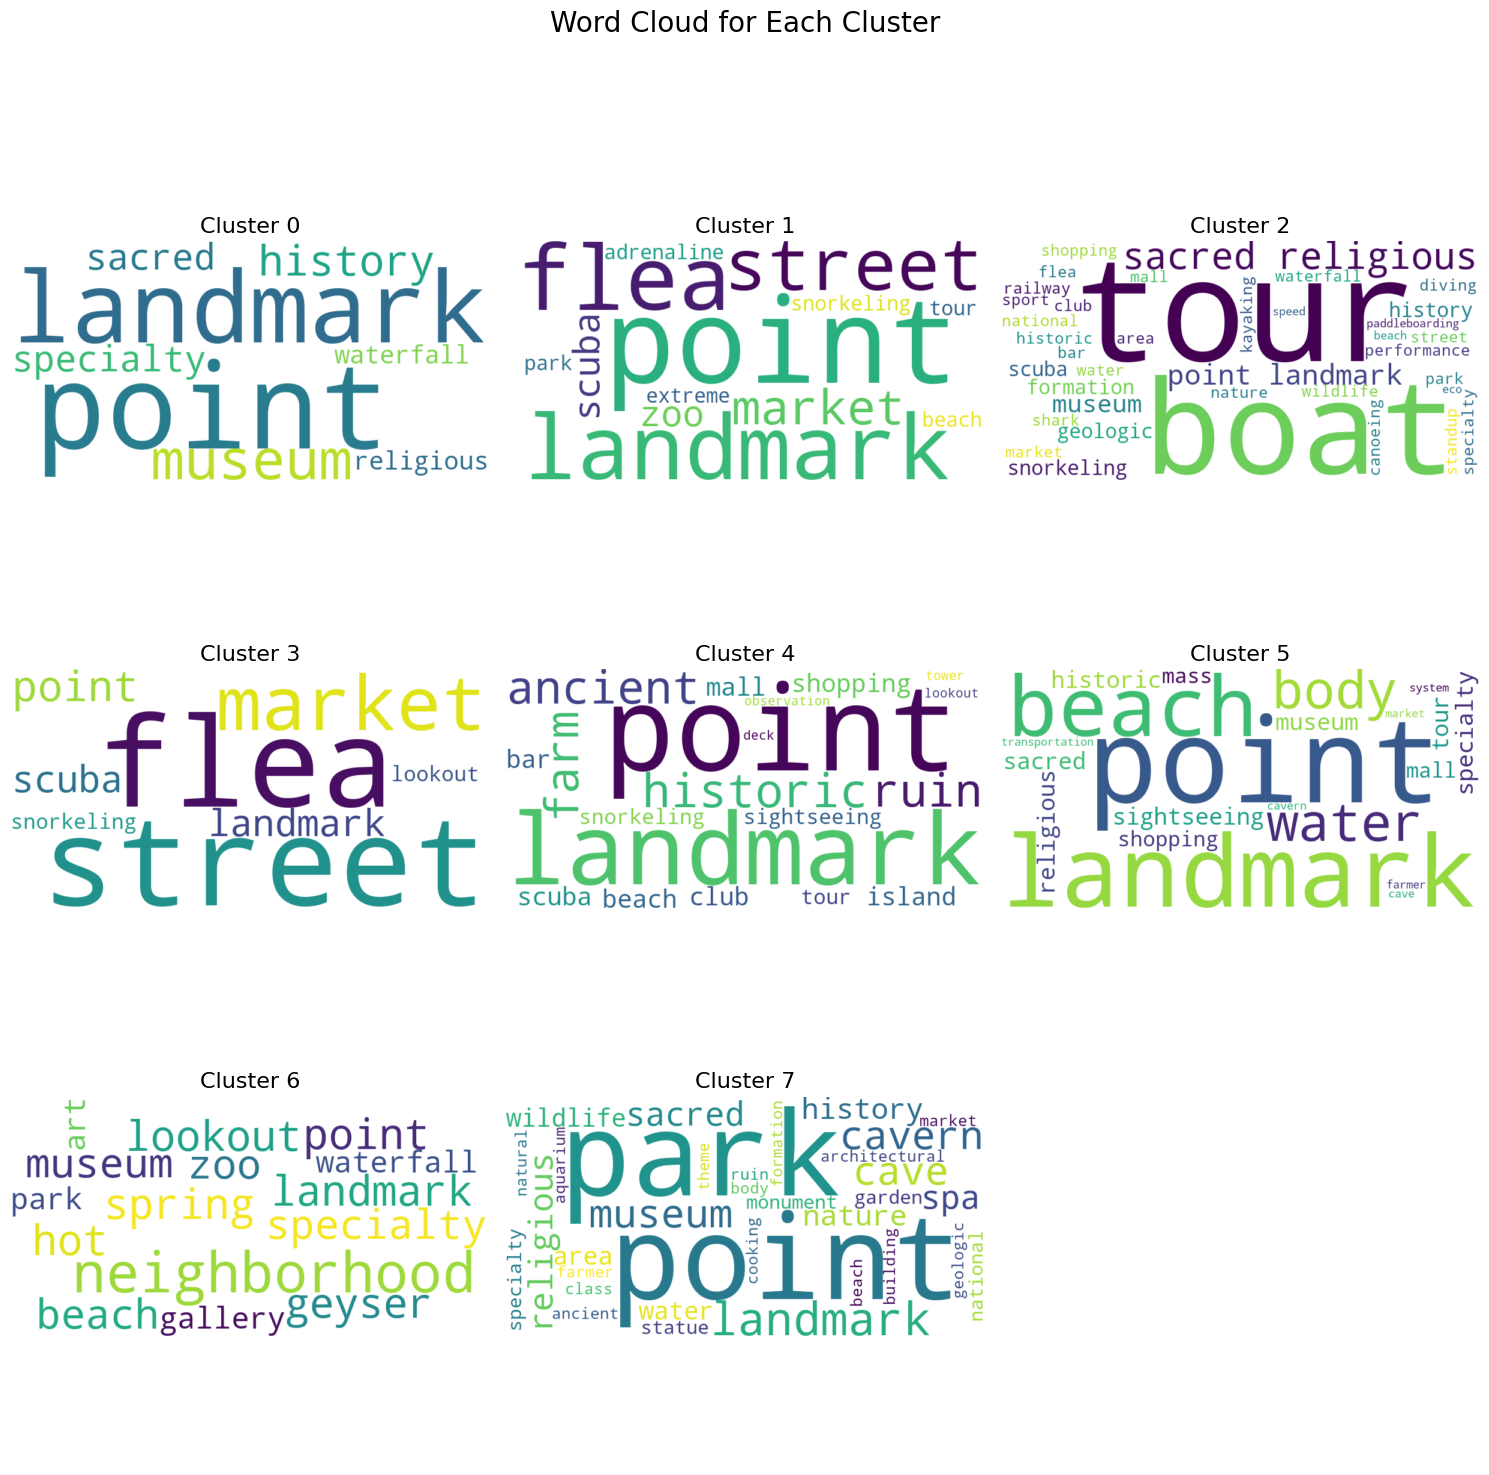

In [20]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

# Process cluster data to ensure all words are flat lists
data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster", fontsize=20)

# Flatten axes for easy iteration (in case rows > 1)
axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()